### Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import load_model

wind_MLP = load_model('wind_MLP.keras')

### Load Datasets & Data Preprocessing

In [4]:
cols = ['u','u_e','u_n']

# Load datasets
df_stn = pd.read_csv('Sikorsky_data.csv')
df_stn = df_stn.rename(columns={'WSPD':'u'})
df_stn['TmStamp'] = pd.to_datetime(df_stn['TmStamp'], format='mixed')
df_stn.set_index('TmStamp', inplace=True)

df_buoy = pd.read_csv('WLIS_data.csv')
df_buoy = df_buoy.rename(columns={'WSPD':'u'})
df_buoy['TmStamp'] = pd.to_datetime(df_buoy['TmStamp'], format='mixed')
df_buoy.set_index('TmStamp', inplace=True)

# Add east and north components
alpha = -13
df_stn['rad'] = np.pi/180 * ((alpha + 630 - df_stn['WDIR']) % 360)
df_stn['u_e'] = df_stn['u'] * np.cos(df_stn['rad'])
df_stn['u_n'] = df_stn['u'] * np.sin(df_stn['rad'])

df_buoy['rad'] = np.pi/180 * ((alpha + 630 - df_buoy['WDIR']) % 360)
df_buoy['u_e'] = df_buoy['u'] * np.cos(df_buoy['rad'])
df_buoy['u_n'] = df_buoy['u'] * np.sin(df_buoy['rad'])

# Transform station wind into buoy wind
wind_T_uc = wind_MLP.predict(df_stn[cols[1:]], verbose=0)
wind_T_u = np.sqrt(wind_T_uc[:, 0]**2 + wind_T_uc[:, 1]**2)
wind_T = np.hstack((wind_T_u.reshape(-1, 1), wind_T_uc))

# Rename columns
df_buoy = df_buoy[['H'] + cols].rename(columns={col: f'{col}_buoy' for col in cols})
df_stn = df_stn[cols].rename(columns={col: f'{col}_stn' for col in cols})
df_T = pd.DataFrame(wind_T, columns=cols).rename(columns={col: f'{col}_T' for col in cols})
df_T.index = df_stn.index

### Distribution of Features & Target

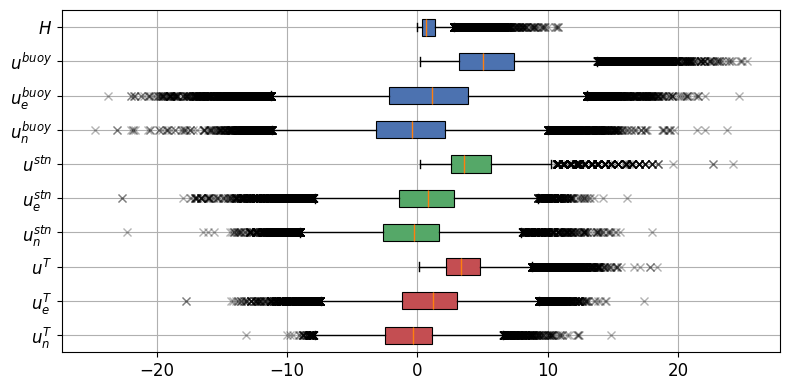

In [5]:
data, colors = [], []
label_buoy = [r'$H$', r'$u^{buoy}$', r'$u_{e}^{buoy}$', r'$u_{n}^{buoy}$']
label_stn = [r'$u^{stn}$', r'$u_{e}^{stn}$', r'$u_{n}^{stn}$']
label_T = [r'$u^{T}$', r'$u_{e}^{T}$', r'$u_{n}^{T}$']
labels = label_buoy + label_stn + label_T

for col in df_buoy.columns:
    data.append(df_buoy[col])
    colors.append('#4C72B0')

for col in df_stn.columns:
    data.append(df_stn[col])
    colors.append('#55A868')

for col in df_T.columns:
    data.append(df_T[col])
    colors.append('#C44E52')

# Box plot
fig, ax = plt.subplots(figsize=(8, 4))
flierprops = dict(marker='x', markerfacecolor='k', alpha=0.3)
box = ax.boxplot(data[::-1], vert=False, patch_artist=True, flierprops=flierprops, boxprops=dict(linewidth=0.8))
for patch, color in zip(box['boxes'], colors[::-1]):
    patch.set_facecolor(color)

ax.set_yticklabels(labels[::-1])
plt.tick_params(axis='both', labelsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()

### Correlation Analysis

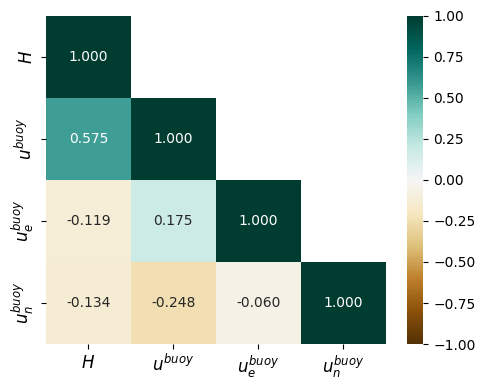

In [6]:
df_corr1 = df_buoy.corr()
df_corr1.columns = label_buoy
df_corr1.index = label_buoy

plt.figure(figsize=(5, 4))
sns.heatmap(df_corr1, vmin=-1, vmax=1, center=0, fmt='.3f', annot=True, 
            cmap='BrBG', mask=np.triu(np.ones_like(df_corr1), 1))
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

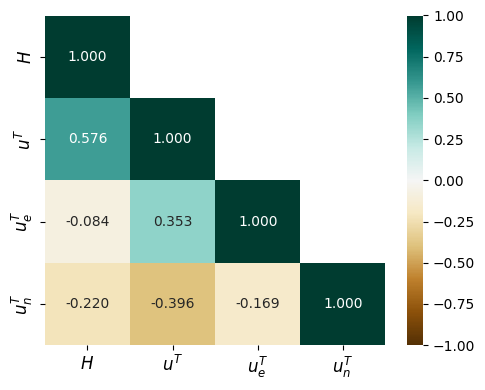

In [7]:
df_corr2 = pd.concat([df_buoy[['H']], df_T], axis=1).corr()
df_corr2.columns = label_buoy[:1] + label_T
df_corr2.index = label_buoy[:1] + label_T

plt.figure(figsize=(5, 4))
sns.heatmap(df_corr2, vmin=-1, vmax=1, center=0, fmt='.3f', annot=True, 
            cmap='BrBG', mask=np.triu(np.ones_like(df_corr2), 1))
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()